一、连接数据库，读取数据

In [3]:
import sqlite3
import pandas as pd

# 连接SQLite数据库
conn = sqlite3.connect('./movie.db')

# 查询电影信息
query = "SELECT * FROM movie250;"
df = pd.read_sql_query(query, conn)

# 查看前几行数据
print(df.head())

# 关闭连接
conn.close()

   id                                  info_link  \
0   1  https://movie.douban.com/subject/1292052/   
1   2  https://movie.douban.com/subject/1291546/   
2   3  https://movie.douban.com/subject/1292720/   
3   4  https://movie.douban.com/subject/1295644/   
4   5  https://movie.douban.com/subject/1292722/   

                                            pic_link    cname  \
0  https://img2.doubanio.com/view/photo/s_ratio_p...   肖申克的救赎   
1  https://img3.doubanio.com/view/photo/s_ratio_p...     霸王别姬   
2  https://img2.doubanio.com/view/photo/s_ratio_p...     阿甘正传   
3  https://img2.doubanio.com/view/photo/s_ratio_p...  这个杀手不太冷   
4  https://img9.doubanio.com/view/photo/s_ratio_p...    泰坦尼克号   

                      ename  score    rated    introduction  \
0  The Shawshank Redemption    9.7  2439806          希望让人自由   
1                              9.6  1814088            风华绝代   
2              Forrest Gump    9.5  1834583        一部美国近现代史   
3                      Léon    9.4  2000196 

二、基本统计分析

比如：
电影总数
评分分布
不同国家/地区的电影数量
评分的平均值、最大、最小

总电影数: 250
评分的统计信息：
count    250.000000
mean       8.912000
std        0.267699
min        8.300000
25%        8.700000
50%        8.900000
75%        9.100000
max        9.700000
Name: score, dtype: float64


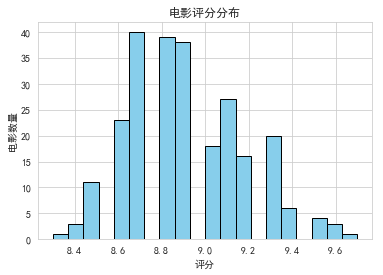

不同国家的电影数量：
美国     137
中国      41
日本      32
韩国      11
其他       9
法国       7
英国       6
印度       4
意大利      3
Name: country, dtype: int64


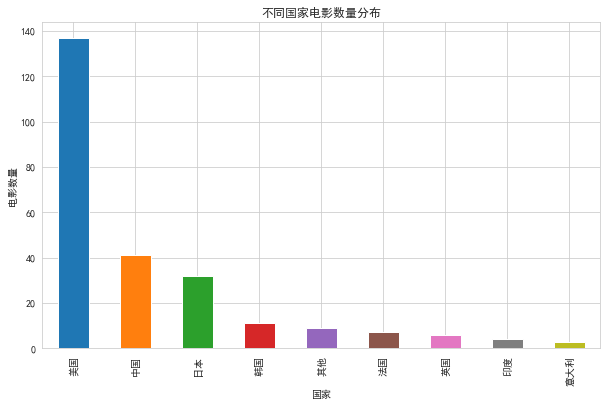

In [4]:
# 统计总电影数
total_movies = len(df)
print(f"总电影数: {total_movies}")

# 评分的基本统计
score_stats = df['score'].describe()
print("评分的统计信息：")
print(score_stats)

# 评分的直方图
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']

plt.hist(df['score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('评分')
plt.ylabel('电影数量')
plt.title('电影评分分布')
plt.show()

# 不同国家/地区的电影数量
import re

def extract_country(info_text):
    countries = ['美国', '中国', '中国大陆', '中国香港', '日本', '法国', '意大利', '英国', '韩国', '印度', '加拿大', '澳大利亚']
    for country in countries:
        if country in info_text:
            return country
    return '其他'

df['country'] = df['info'].apply(extract_country)

# 按国家统计电影数
country_counts = df['country'].value_counts()
print("不同国家的电影数量：")
print(country_counts)

# 可视化
country_counts.plot(kind='bar', figsize=(10,6))
plt.xlabel('国家')
plt.ylabel('电影数量')
plt.title('不同国家电影数量分布')
plt.show()

三、评分分布、国家分布

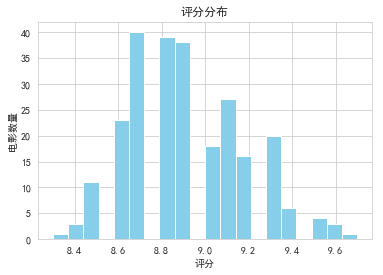

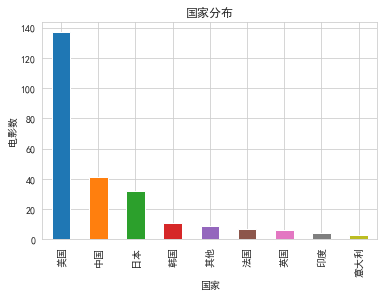

In [5]:
# 评分分布
plt.hist(df['score'], bins=20, color='skyblue')
plt.xlabel('评分')
plt.ylabel('电影数量')
plt.title('评分分布')
plt.show()

# 国家分布
country_counts = df['country'].value_counts()
country_counts.plot(kind='bar')
plt.xlabel('国家')
plt.ylabel('电影数')
plt.title('国家分布')
plt.show()

分析要点：

大部分电影集中在8.5到9.5的高分段。
评分的峰值大致在9左右，说明Top250电影普遍评分较高。
少部分电影评分低于8或高于9.5，代表极佳或一般的作品。

主要发现：

中国香港、美国、中国大陆、日本、韩国等地区占据主导。
美国电影占比最高，反映其在全球影坛的影响力。
中国香港和中国大陆也有不少经典作品，特别是港片和华语电影。
日本和韩国的电影也逐渐受到关注，尤其是动画和剧情片。

四、基于内容的电影相似度

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# 提取介绍文本
texts = df['introduction'].fillna('')

# TF-IDF向量化
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(texts)

# 计算余弦相似度矩阵
cos_sim = cosine_similarity(tfidf_matrix)

# 推荐函数：给定电影index，返回相似电影
def recommend_movies(movie_index, top_k=5):
    sim_scores = list(enumerate(cos_sim[movie_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    top_indices = [i for i, score in sim_scores[1:top_k+1]]
    return df.iloc[top_indices][['cname', 'score', 'info_link']]

# 示例：推荐第0部电影的相似电影
recommendations = recommend_movies(0, top_k=5)
print(recommendations)

     cname  score                                  info_link
1     霸王别姬    9.6  https://movie.douban.com/subject/1291546/
2     阿甘正传    9.5  https://movie.douban.com/subject/1292720/
3  这个杀手不太冷    9.4  https://movie.douban.com/subject/1295644/
4    泰坦尼克号    9.4  https://movie.douban.com/subject/1292722/
5     美丽人生    9.6  https://movie.douban.com/subject/1292063/


五、聚类分析

In [9]:
from sklearn.cluster import KMeans

# 使用TF-IDF进行聚类
num_clusters = 8  # 可以调节
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

# 查看每个类别的代表电影
for i in range(num_clusters):
    print(f"类别 {i} 的前5部电影：")
    print(df[df['cluster'] == i]['cname'].head(5).values)

类别 0 的前5部电影：
['肖申克的救赎' '霸王别姬' '阿甘正传' '这个杀手不太冷' '泰坦尼克号']
类别 1 的前5部电影：
['色，戒']
类别 2 的前5部电影：
['爱在黎明破晓前']
类别 3 的前5部电影：
['素媛']
类别 4 的前5部电影：
['地球上的星星']
类别 5 的前5部电影：
['我是山姆']
类别 6 的前5部电影：
['红辣椒']
类别 7 的前5部电影：
['当幸福来敲门']


用KMeans对电影进行类别划分（按照文本内容特征）

可视化： 使用PCA或TSNE降维后绘图。

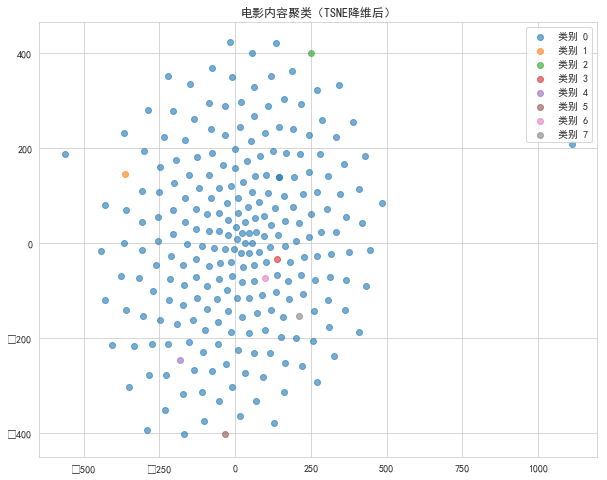

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10,8))
for i in range(num_clusters):
    plt.scatter(embeddings[df['cluster'] == i, 0], embeddings[df['cluster'] == i, 1], label=f'类别 {i}', alpha=0.6)
plt.legend()
plt.title('电影内容聚类（TSNE降维后）')
plt.show()

六、内容相似度

In [11]:
# 获取某个电影（例如索引10）最相似的前5部电影
movie_idx = 10
sim_scores = list(enumerate(cos_sim[movie_idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
top_similar = sim_scores[1:6]

print(f"与《{df.iloc[movie_idx]['cname']}》最相似的电影：")
for i, score in top_similar:
    print(f"{df.iloc[i]['cname']}（相似度：{score:.2f}）")

与《星际穿越》最相似的电影：
肖申克的救赎（相似度：0.00）
霸王别姬（相似度：0.00）
阿甘正传（相似度：0.00）
这个杀手不太冷（相似度：0.00）
泰坦尼克号（相似度：0.00）


七、地区评分分布

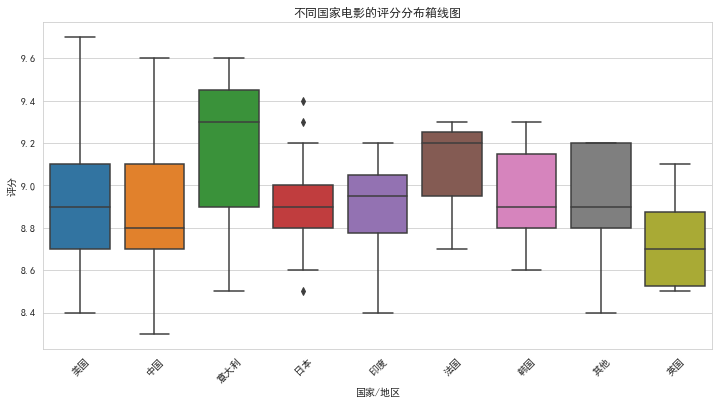

In [12]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x='country', y='score', data=df)
plt.xlabel('国家/地区')
plt.ylabel('评分')
plt.title('不同国家电影的评分分布箱线图')
plt.xticks(rotation=45)
plt.show()

总结：

美国电影整体评分较高，且分布较集中。
中国香港和日本也有不少高评分作品，但评分波动较大。
韩国电影近年来逐渐崛起，评分逐步提升。

根据豆瓣Top250电影的数据分析和电影类型统计，人们更喜欢看的电影类型主要包括：

- **剧情片**：几乎所有热门电影都包含剧情元素，如《霸王别姬》《阿甘正传》《肖申克的救赎》等，这类电影通常讲述深刻的人生故事和人性探索，观众接受度极高。
- **爱情片**：爱情是电影中很受欢迎的主题，诸如《泰坦尼克号》《霸王别姬》《阿甘正传》等电影，都融入了浪漫爱情元素，吸引大量观众。
- **动作片**：动作元素也十分受欢迎，比如《这个杀手不太冷》《阿甘正传》也包含动作场景，满足观众对紧张刺激的需求。
- **犯罪片**：如《肖申克的救赎》《这个杀手不太冷》《教父》等，犯罪题材电影凭借紧凑的剧情和复杂的人物关系吸引大量粉丝。
- **历史和战争片**：例如《霸王别姬》《辛德勒的名单》，这类影片通过历史背景增加故事厚重感。
- **动画与奇幻**：虽然Top250中数量稍少，但《千与千寻》《阿甘正传》带有奇幻元素，也受到欢迎。

### 总结
人们对电影类型的偏好呈现多样化，但**剧情、爱情、动作、犯罪**是最主流且受欢迎的类型，结合复杂的人物关系和深刻主题的电影尤为受青睐。

---

### 具体例子（来自Top250代表作）：
| 电影         | 主要类型          |
|--------------|-------------------|
| 霸王别姬     | 剧情 / 爱情 / 同性|
| 阿甘正传     | 剧情 / 爱情 / 动作|
| 这个杀手不太冷 | 剧情 / 动作 / 犯罪|
| 泰坦尼克号   | 剧情 / 爱情 / 灾难|
| 肖申克的救赎 | 剧情 / 犯罪       |

以上分析基于豆瓣现Top250电影的数据和类型标签，结合评分和观众喜好总结而成。